In [1]:
import os
import random
import csv

# Path to your dataset
dataset_path = "/mnt/abka03/xlvlm_data/coco_cc0_plus/val"
output_csv = "mcq_dataset.csv"

# Get all class names
classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

data = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            continue

        # Ensure unique wrong options
        wrong_options = random.sample([c for c in classes if c != cls], 3)
        options = wrong_options + [cls]
        random.shuffle(options)

        # Remove underscores from each option
        options = [opt.replace('_', '') for opt in options]

        question = "What object is in this image?"
        data.append({
            "image_path": img_path,
            "question": question,
            "options": options,
            "ground_truth": cls.replace('_', '')
        })

# Write to CSV
with open(output_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["image_path", "question", "options", "ground_truth"])
    writer.writeheader()
    for row in data:
        # Convert options list to a string for CSV
        row["options"] = ", ".join(row["options"])
        writer.writerow(row)

print(f"MCQ-I dataset saved to {output_csv}")


MCQ-I dataset saved to mcq_dataset.csv


In [1]:
import os
import json
import requests
from collections import defaultdict

# CONFIG
ANNOTATION_DIR = "/mnt/abka03/raw_data_download/coco_cc0/annotations"
OUTPUT_DIR = "coco_cc0_plus"
IMAGES_PER_CATEGORY = 3

def get_annotation_file(split):
    return os.path.join(ANNOTATION_DIR, f"instances_{split}2017.json")

def get_caption_file(split):
    return os.path.join(ANNOTATION_DIR, f"captions_{split}2017.json")

def load_coco_data(annotation_file, caption_file):
    with open(annotation_file, "r") as f:
        data = json.load(f)
    with open(caption_file, "r") as f:
        captions_data = json.load(f)

    # Filter licenses: CC0 or ID > 5
    commercial_licenses = {lic["id"] for lic in data["licenses"] if lic["id"] > 5 or "CC0" in lic["name"]}
    print("Using licenses:", commercial_licenses)

    # Filter images by license
    images_by_id = {img["id"]: img for img in data["images"] if img["license"] in commercial_licenses}

    categories = {cat["id"]: cat["name"] for cat in data["categories"]}
    category_images = defaultdict(set)
    annotations_by_image = defaultdict(list)

    for ann in data["annotations"]:
        if ann["image_id"] in images_by_id:
            category_images[ann["category_id"]].add(ann["image_id"])
            annotations_by_image[ann["image_id"]].append(ann)

    captions_by_image = defaultdict(list)
    for ann in captions_data["annotations"]:
        if ann["image_id"] in images_by_id:
            captions_by_image[ann["image_id"]].append(ann["caption"])

    return images_by_id, categories, category_images, annotations_by_image, captions_by_image

def download_image(url, save_path):
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            return True
    except Exception as e:
        print(f"Download failed: {e}")
    return False

def process_split(split_name, annotation_dir, output_dir):
    annotation_file = get_annotation_file(split_name)
    caption_file = get_caption_file(split_name)
    print(f"Processing {split_name} split...")

    images_by_id, categories, category_images, annotations_by_image, captions_by_image = load_coco_data(annotation_file, caption_file)

    for cat_id, img_ids in category_images.items():
        cat_name = categories[cat_id]
        folder_path = os.path.join(output_dir, split_name, cat_name)
        os.makedirs(folder_path, exist_ok=True)

        downloaded = 0
        for img_id in img_ids:
            if downloaded >= IMAGES_PER_CATEGORY:
                break
            img_info = images_by_id[img_id]
            filename = os.path.join(folder_path, f"{img_id}.jpg")
            meta_file = os.path.join(folder_path, f"{img_id}.json")

            if download_image(img_info["coco_url"], filename):
                downloaded += 1
                metadata = {
                    "image_id": img_id,
                    "file_name": img_info["file_name"],
                    "captions": captions_by_image[img_id],
                    "annotations": annotations_by_image[img_id]
                }
                with open(meta_file, "w") as f:
                    json.dump(metadata, f, indent=2)
                print(f"[{split_name}/{cat_name}] Downloaded {downloaded}/{IMAGES_PER_CATEGORY} (with captions & segments)")

# --- Run for train and val splits ---
for split in ["train", "val"]:
    process_split(split, ANNOTATION_DIR, OUTPUT_DIR)

print(f"Done! Images with captions & segmentation saved in: {OUTPUT_DIR}")

Processing train split...
Using licenses: {8, 6, 7}
Using licenses: {8, 6, 7}
[train/dog] Downloaded 1/3 (with captions & segments)
[train/dog] Downloaded 1/3 (with captions & segments)
[train/dog] Downloaded 2/3 (with captions & segments)
[train/dog] Downloaded 2/3 (with captions & segments)
[train/dog] Downloaded 3/3 (with captions & segments)
[train/dog] Downloaded 3/3 (with captions & segments)
[train/potted plant] Downloaded 1/3 (with captions & segments)
[train/potted plant] Downloaded 1/3 (with captions & segments)
[train/potted plant] Downloaded 2/3 (with captions & segments)
[train/potted plant] Downloaded 2/3 (with captions & segments)
[train/potted plant] Downloaded 3/3 (with captions & segments)
[train/potted plant] Downloaded 3/3 (with captions & segments)
[train/tv] Downloaded 1/3 (with captions & segments)
[train/tv] Downloaded 1/3 (with captions & segments)
[train/tv] Downloaded 2/3 (with captions & segments)
[train/tv] Downloaded 2/3 (with captions & segments)
[train/t

In [2]:
annotation_path = "/mnt/abka03/Projects/xl-vlms/notebooks/coco_cc0_plus/val/fork/181796.json"
image_path = "/mnt/abka03/Projects/xl-vlms/notebooks/coco_cc0_plus/val/fork/181796.jpg"

/tmp/ipykernel_99679/4041836721.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(annotation.get("annotations", [])))


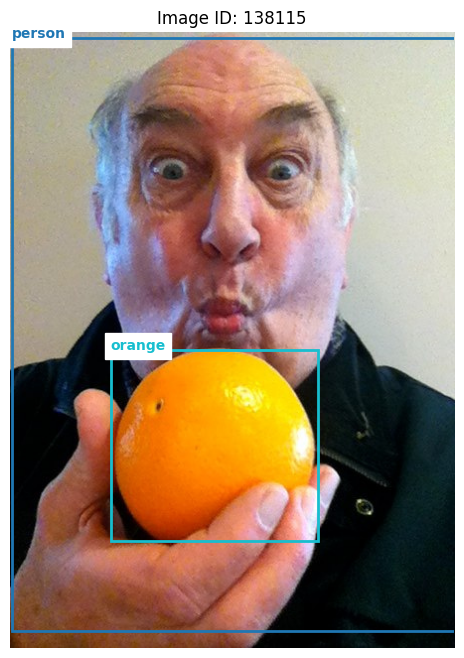

In [8]:
import json
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Load category map from COCO annotation file
coco_ann_path = "/mnt/abka03/raw_data_download/coco_cc0/annotations/instances_val2017.json"
with open(coco_ann_path, "r") as f:
    coco_data = json.load(f)
category_map = {str(cat["id"]): cat["name"] for cat in coco_data["categories"]}

# Load image and annotation
annotation_path = "/mnt/abka03/Projects/xl-vlms/notebooks/coco_cc0_plus/val/orange/138115.json"
image_path = "/mnt/abka03/Projects/xl-vlms/notebooks/coco_cc0_plus/val/orange/138115.jpg"

with open(annotation_path, "r") as f:
    annotation = json.load(f)
img = Image.open(image_path)

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img)

# Color palette for annotations
colors = plt.cm.get_cmap('tab10', len(annotation.get("annotations", [])))

# Show bounding boxes and category names
for idx, ann in enumerate(annotation.get("annotations", [])):
    color = colors(idx) if len(annotation.get("annotations", [])) > 1 else (1,0,0,0.4)
    bbox = ann.get('bbox', None)
    category_id = ann.get('category_id', None)
    category_name = category_map.get(str(category_id), str(category_id)) if category_id is not None else 'Unknown'
    if bbox:
        x, y, w, h = bbox
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, category_name, fontsize=10, color=color, backgroundcolor='white', weight='bold')

plt.title(f"Image ID: {annotation.get('image_id', '')}")
plt.axis('off')
plt.show()

In [1]:
!pip install -U git+https://github.com/luca-medeiros/lang-segment-anything.git

  Cloning https://github.com/luca-medeiros/lang-segment-anything.git to /tmp/pip-req-build-8ya1vx_d
  Running command git clone --filter=blob:none --quiet https://github.com/luca-medeiros/lang-segment-anything.git /tmp/pip-req-build-8ya1vx_d
  Resolved https://github.com/luca-medeiros/lang-segment-anything.git to commit 918043ed4666eea04da88aa179eb8d27ef4b1a1d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/facebookresearch/segment-anything-2 (to revision c2ec8e14a185632b0a5d8b161928ceb50197eddc) to /tmp/pip-install-8n3w5bbn/sam-2_63c8768b053d4ecb8f8e5c5d26d40cee
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything-2 /tmp/pip-install-8n3w5bbn/sam-2_63c8768b053d4ecb8f8e5c5d26d40cee
  Running command git rev-parse -q --verify 'sha^c2ec8e14a185632b0a5d8b161928ceb50197eddc'
  Running command git fetch -q https://github.co

One or both local paths not provided. Loading from Hugging Face Hub: IDEA-Research/grounding-dino-base
Predicting 1 masks
Predicted 1 masks
<class 'list'> 1
First result keys: ['scores', 'boxes', 'text_labels', 'labels', 'masks', 'mask_scores']
Predicting 1 masks
Predicted 1 masks
<class 'list'> 1
First result keys: ['scores', 'boxes', 'text_labels', 'labels', 'masks', 'mask_scores']


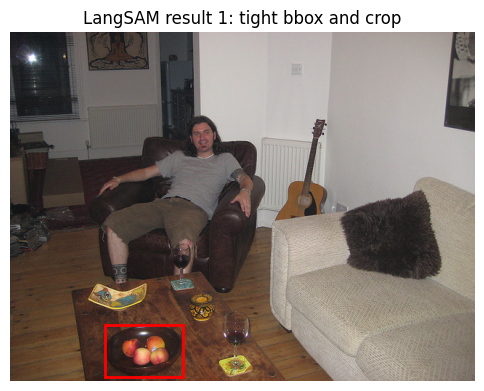

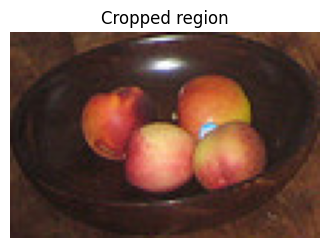

In [11]:
from PIL import Image
from lang_sam import LangSAM
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
try:
    import torch  # optional, for dtype check
except Exception:
    torch = None

model = LangSAM()
image_pil = Image.open("/mnt/abka03/Projects/xl-vlms/data/train/apple/417834.jpg").convert("RGB")
text_prompt = "apple"
results = model.predict([image_pil], [text_prompt])
print(type(results), len(results))
print("First result keys:", list(results[0].keys()) if results else [])

# Use mask to derive a precise/tight bbox, then draw and crop
for i, result in enumerate(results):
    boxes = result.get("boxes")
    masks = result.get("masks")
    if masks is None:
        masks = result.get("mask")
    
    # Fallback: if mask missing, use provided bbox as-is (assumed [x, y, w, h])
    if masks is None and boxes is not None:
        bbox = np.array(boxes[0], dtype=float)
        x, y, w, h = bbox
    else:
        # Normalize masks to boolean numpy array (H, W) for this sample
        m = masks[0] if isinstance(masks, (list, tuple)) else masks
        # If batched or 3D, reduce to first mask
        if hasattr(m, "ndim") and m.ndim > 2:
            m = m[0]
        # Convert to numpy
        if torch is not None and hasattr(m, "detach") and hasattr(m, "cpu"):
            m_np = m.detach().cpu().numpy()
        else:
            m_np = np.array(m)
        # Ensure 2D
        if m_np.ndim > 2:
            m_np = m_np.squeeze()
        # Binarize mask
        if m_np.dtype != bool:
            m_bin = m_np > 0.5 if np.issubdtype(m_np.dtype, np.floating) else m_np > 0
        else:
            m_bin = m_np
        
        # If mask empty, fallback to boxes
        if not m_bin.any():
            if boxes is None:
                print("Empty mask and no boxes; skipping this result.")
                continue
            bbox = np.array(boxes[0], dtype=float)
            x, y, w, h = bbox
        else:
            # Compute tight bbox from mask indices
            ys, xs = np.where(m_bin)
            x_min, x_max = xs.min(), xs.max()
            y_min, y_max = ys.min(), ys.max()
            x, y = float(x_min), float(y_min)
            w, h = float(x_max - x_min + 1), float(y_max - y_min + 1)  # inclusive bounds
    
    # Clamp bbox to image bounds
    W, H = image_pil.size
    x0 = max(0.0, min(x, W - 1))
    y0 = max(0.0, min(y, H - 1))
    x1 = max(0.0, min(x + w, W))
    y1 = max(0.0, min(y + h, H))
    
    # Convert to integer crop bounds (inclusive bbox -> right/bottom use ceil)
    left = int(np.floor(x0))
    top = int(np.floor(y0))
    right = int(np.ceil(x1))
    bottom = int(np.ceil(y1))
    
    # Sanity ensure minimum size
    if right <= left:
        right = min(W, left + 1)
    if bottom <= top:
        bottom = min(H, top + 1)
    
    # Draw rectangle on original
    plt.figure(figsize=(6, 6))
    plt.imshow(image_pil)
    rect = patches.Rectangle((left, top), right - left, bottom - top, linewidth=2, edgecolor="red", facecolor="none")
    plt.gca().add_patch(rect)
    plt.title(f"LangSAM result {i+1}: tight bbox and crop")
    plt.axis("off")
    plt.show()
    
    # Precise crop
    cropped_image = image_pil.crop((left, top, right, bottom))
    plt.figure(figsize=(4, 4))
    plt.imshow(cropped_image)
    plt.axis("off")
    plt.title("Cropped region")
    plt.show()